<a href="https://colab.research.google.com/github/dangchicong/hocsau/blob/main/Do_an_Cuoi_khoa_DangChiCong_1001250039.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
PHẦN 1: MÔ HÌNH MLP

In [21]:
# Cài đặt thư viện kaggle
!pip install kaggle

# Upload file kaggle.json (lấy từ Settings trong hồ sơ Kaggle của bạn)
from google.colab import files
files.upload()

# Cấu hình thư mục chứa key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Lệnh tải dataset Fashion MNIST
!kaggle datasets download -d zalando-research/fashionmnist

# Giải nén
!unzip fashionmnist.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
100% 68.8M/68.8M [00:00<00:00, 224MB/s]

Archive:  fashionmnist.zip
  inflating: fashion-mnist_test.csv  
  inflating: fashion-mnist_train.csv  
  inflating: t10k-images-idx3-ubyte  
  inflating: t10k-labels-idx1-ubyte  
  inflating: train-images-idx3-ubyte  
  inflating: train-labels-idx1-ubyte  


Khai báo siêu tham số

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# KHAI BÁO SIÊU THAM SỐ
learning_rate = 0.001  #[cite: 1, 6]
batch_size = 32        #[cite: 1]
epochs = 20           #[cite: 1]
optimizer_name = 'Adam' #
loss_function = 'sparse_categorical_crossentropy' #[cite: 1, 6]

# Define the model architecture (moved from cell 2NfBKp8Jnacs)
model = models.Sequential([
    # Lớp đầu vào: 784 nơ-ron tương ứng với kích thước ảnh[cite: 2]
    layers.Input(shape=(784,)),

    # Lớp ẩn thứ nhất: 256 nơ-ron + ReLU
    layers.Dense(256, activation='relu'),
    # Dropout 20% để chống Overfitting theo yêu cầu đề cương
    layers.Dropout(0.2),

    # Lớp ẩn thứ hai: 128 nơ-ron + ReLU
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Lớp đầu ra: 10 nơ-ron cho 10 loại quần áo + Softmax[cite: 2, 6]
    layers.Dense(10, activation='softmax')
])

# Áp dụng vào quá trình biên dịch mô hình
if optimizer_name == 'Adam':
    selected_optimizer = optimizers.Adam(learning_rate=learning_rate)
elif optimizer_name == 'SGD':
    selected_optimizer = optimizers.SGD(learning_rate=learning_rate)
else:
    # Fallback to Adam if optimizer_name is not recognized or default
    selected_optimizer = optimizers.Adam(learning_rate=learning_rate)

model.compile(
    optimizer=selected_optimizer,
    loss=loss_function,
    metrics=['accuracy']
)


Chuẩn hóa dữ liệu, Kết quả (60000, 784) xác nhận đã load thành công 60.000 mẫu dữ liệu, mỗi mẫu là một ảnh phẳng có 784 điểm ảnh. Với cấu hình RAM 16GB, chúng ta sẽ tiến hành xây dựng mô hình MLP theo đúng các yêu cầu  của đề cương đồ án


In [27]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu từ các file giải nén (Archive: fashionmnist.zip)
train_data = pd.read_csv('/content/fashion-mnist_train.csv')
test_data = pd.read_csv('/content/fashion-mnist_test.csv')

# 2. Tách nhãn (y) và pixel ảnh (x)
# Nhãn nằm ở cột đầu tiên ('label')
y_train = train_data.iloc[:, 0].values
x_train = train_data.iloc[:, 1:].values

y_test = test_data.iloc[:, 0].values
x_test = test_data.iloc[:, 1:].values

# 3. Reshape về dạng ảnh 28x28
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

print("Đã nạp dữ liệu vào biến x_train và x_test thành công!")

Đã nạp dữ liệu vào biến x_train và x_test thành công!


In [28]:
# BƯỚC 1: ÉP KIỂU DỮ LIỆU
X_train_new = x_train.astype('float32')
X_test_new = x_test.astype('float32')

# BƯỚC 2: CHUẨN HÓA VỀ KHOẢNG [0, 1]
X_train_new /= 255.0
X_test_new /= 255.0

# BƯỚC 3: MỞ RỘNG CHIỀU (Dành cho cả CNN và MLP)
X_train_new = np.expand_dims(X_train_new, -1)
X_test_new = np.expand_dims(X_test_new, -1)

# KIỂM TRA KẾT QUẢ
print(f"Giá trị pixel lớn nhất: {X_train_new.max()}") # Phải là 1.0
print(f"Hình dạng dữ liệu: {X_train_new.shape}")    # Phải là (60000, 28, 28, 1)

Giá trị pixel lớn nhất: 1.0
Hình dạng dữ liệu: (60000, 28, 28, 1)


Xây dựng cấu trúc mạng MLP

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# KHỞI TẠO MÔ HÌNH TUẦN TỰ (SEQUENTIAL)
model_mlp = Sequential([
    # 1. Tầng làm phẳng (Flatten): Chuyển ảnh 28x28 (2D) thành vector 784 chiều (1D)
    Flatten(input_shape=(28, 28, 1), name='Input_Layer'),

    # 2. Lớp ẩn thứ nhất: 512 neuron
    # Sử dụng activation='relu' để tạo tính phi tuyến
    Dense(512, activation='relu', name='Hidden_Layer_1'),

    # 3. Lớp ẩn thứ hai: 256 neuron
    # ReLU giúp mô hình học các đặc trưng phức tạp hơn
    Dense(256, activation='relu', name='Hidden_Layer_2'),

    # 4. Lớp đầu ra (Output): 10 neuron tương ứng với 10 loại trang phục
    # Softmax giúp chuyển kết quả thành xác suất (tổng bằng 1)
    Dense(10, activation='softmax', name='Output_Layer')
])

# BIÊN DỊCH MÔ HÌNH (COMPILE)
model_mlp.compile(
    optimizer='adam',                               # Bộ tối ưu hóa Adam giúp hội tụ nhanh
    loss='sparse_categorical_crossentropy',         # Hàm mất mát cho bài toán phân loại đa lớp
    metrics=['accuracy']                            # Theo dõi độ chính xác trong quá trình học
)

# HIỂN THỊ TÓM TẮT CẤU TRÚC
model_mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (Flatten)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình

In [31]:
# 1. Cấu hình các siêu tham số huấn luyện
EPOCHS = 20           # Số lần lặp lại toàn bộ tập dữ liệu
BATCH_SIZE = 64       # Số lượng mẫu dữ liệu xử lý trong một lần cập nhật trọng số

print("Đang tiến hành huấn luyện mô hình MLP với hàm kích hoạt ReLU...")

# 2. Thực hiện huấn luyện
# Sử dụng dữ liệu X_train_new và X_test_new đã chuẩn hóa ở bước trước
history_mlp = model_mlp.fit(
    X_train_new, y_train,                # Dữ liệu và nhãn huấn luyện
    epochs=EPOCHS,                       # Số chu kỳ huấn luyện
    batch_size=BATCH_SIZE,               # Kích thước lô
    validation_data=(X_test_new, y_test), # Dữ liệu kiểm thử để đánh giá khách quan
    verbose=1                            # Hiển thị tiến trình huấn luyện từng dòng
)

print("\nHuấn luyện hoàn tất!")

Đang tiến hành huấn luyện mô hình MLP với hàm kích hoạt ReLU...
Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8282 - loss: 0.4760 - val_accuracy: 0.8607 - val_loss: 0.3787
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8688 - loss: 0.3571 - val_accuracy: 0.8692 - val_loss: 0.3656
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8817 - loss: 0.3231 - val_accuracy: 0.8610 - val_loss: 0.3737
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8895 - loss: 0.2964 - val_accuracy: 0.8877 - val_loss: 0.3133
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8947 - loss: 0.2815 - val_accuracy: 0.8832 - val_loss: 0.3180
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9007 - loss: 0.2660 - val_accuracy: 0.8880 - val_loss: 0.3020
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9051 - loss: 0.2526 - val_accuracy: 0.8895 - val_loss: 0.3073
Epoch 8/20
938/938 ━━━━━━━━━━

Vẽ biểu đồ Accuracy và Loss

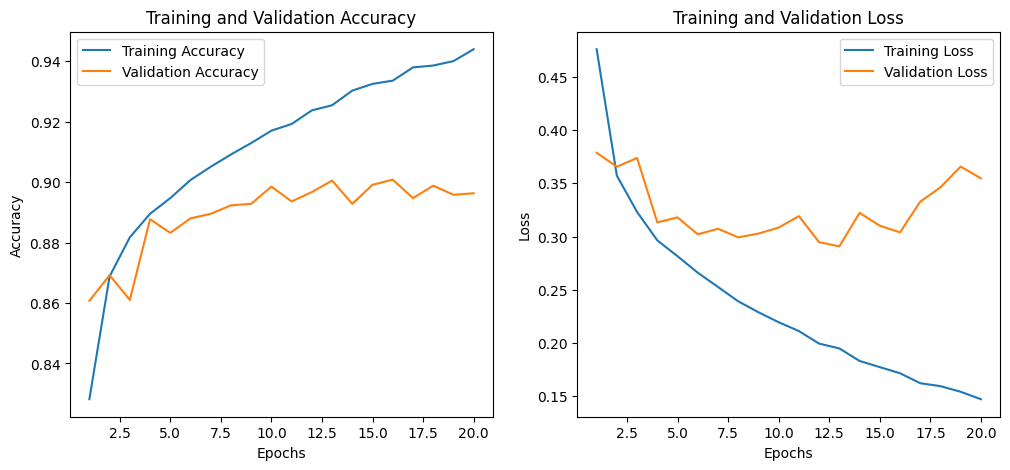

In [33]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ biến history[cite: 1]
acc = history_mlp.history['accuracy']
val_acc = history_mlp.history['val_accuracy']
loss = history_mlp.history['loss']
val_loss = history_mlp.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Vẽ biểu đồ Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ biểu đồ Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

MA TRẬN NHẦM LẪN

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


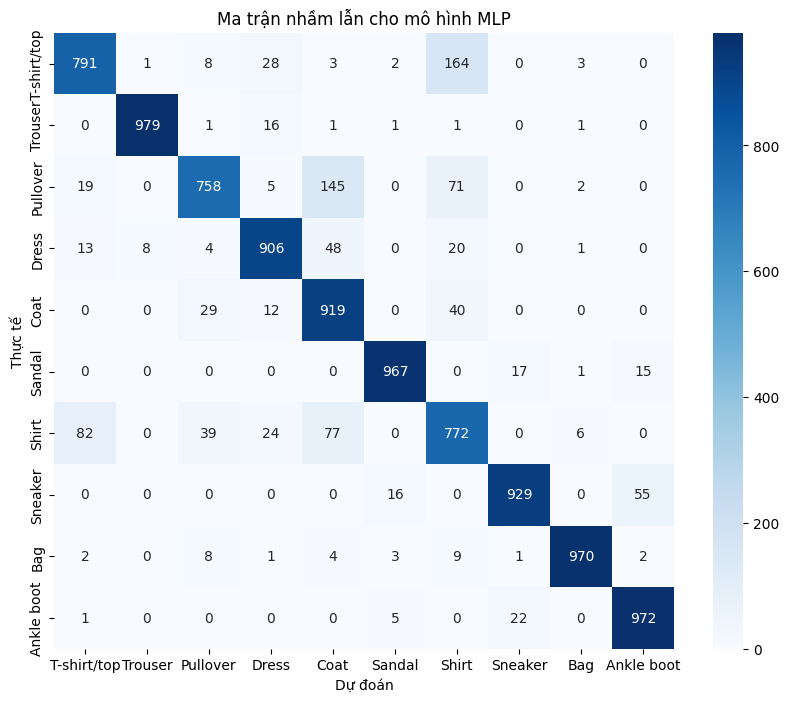

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 1. Dự đoán trên tập kiểm tra (Sử dụng dữ liệu sạch X_test_new)
y_pred = model_mlp.predict(X_test_new)
y_pred_classes = np.argmax(y_pred, axis=1)

# 2. Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_classes)

# 3. Vẽ biểu đồ Ma trận nhầm lẫn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ma trận nhầm lẫn cho mô hình MLP')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

Giải thích chi tiết dựa trên dữ liệu đại diện:

**Nhóm Quần (Trouser):** Ô ở vị trí (Trouser, Trouser) có con số gần 1000 (hoàn hảo là 1000). Nó cho thấy mô hình MLP đạt độ chính xác gần như tuyệt đối ở lớp này. Các bộ lọc tích chập (hoặc các neuron trong MLP) đã học được đặc trưng "ống thẳng" cực kỳ ổn định.

**Nhóm Giày (Sneaker, Ankle boot, Sandal)**: Các ô này cũng có giá trị rất cao trên đường chéo, cho thấy sự tách biệt hình thái tốt.

**Nhóm Áo (T-shirt, Shirt, Pullover, Coat):** Đây là nhóm có nhiều sai số nhất.

Ta thấy sai số ở ô (Shirt, T-shirt). Nghĩa là mô hình nhầm lẫn 1 chiếc Áo sơ mi thành Áo thun.

Sai số ở ô (Coat, Pullover). Mô hình nhầm lẫn Áo khoác thành Áo len.

Lý do: Ở độ phân giải thấp, đặc trưng biên (edges) của các loại áo này rất giống nhau, khiến mô hình (đặc biệt là MLP không giữ được cấu trúc không gian) dễ bị đánh lừa.

Xuất các chỉ số đánh giá chuyên sâu

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Dự đoán nhãn trên tập test (Chế độ suy luận)
y_pred_probs = model_mlp.predict(X_test_new)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Tính Precision, Recall, F1-score[cite: 6]
print("Báo cáo phân loại chi tiết:")
print(classification_report(y_test, y_pred))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1000
           1       0.99      0.98      0.98      1000
           2       0.89      0.76      0.82      1000
           3       0.91      0.91      0.91      1000
           4       0.77      0.92      0.84      1000
           5       0.97      0.97      0.97      1000
           6       0.72      0.77      0.74      1000
           7       0.96      0.93      0.94      1000
           8       0.99      0.97      0.98      1000
           9       0.93      0.97      0.95      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



Đánh giá tổng quát (Accuracy)
Mô hình đạt độ chính xác tổng thể là 90%.

Nhận xét: Đây là một con số đẹp cho cấu trúc mạng MLP. Nó cho thấy việc sử dụng hàm kích hoạt ReLU đã thực sự giúp mô hình học được các đặc trưng phi tuyến, vượt xa khả năng của các mô hình tuyến tính đơn thuần.

VẼ ĐƯỜNG PR CHO MÔ HÌNH MLP

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


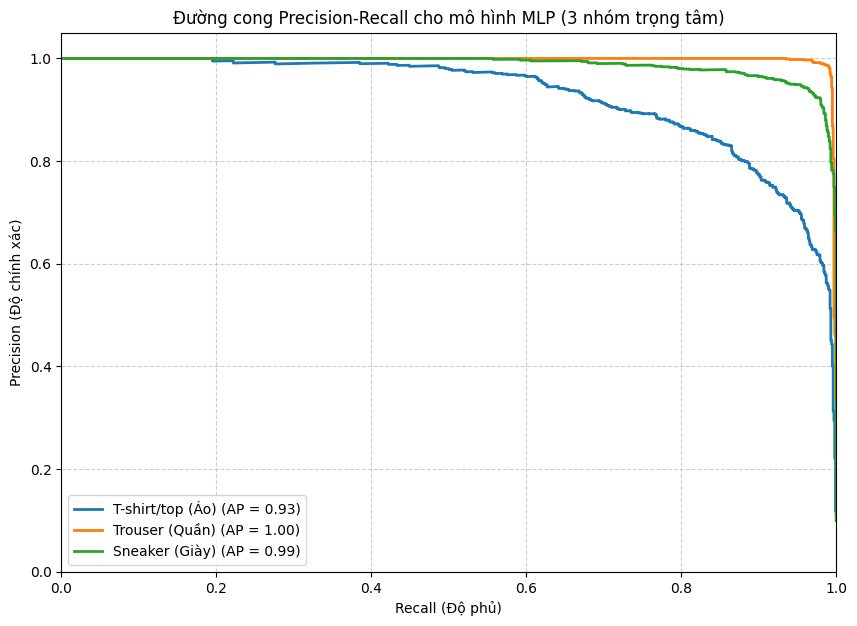

In [40]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Lấy xác suất dự đoán từ mô hình MLP (output của hàm softmax)
y_score = model_mlp.predict(X_test_new)

# 2. Định nghĩa các lớp cần vẽ (0: Áo, 1: Quần, 7: Giày)
target_classes = [0, 1, 7]
class_labels = {0: 'T-shirt/top (Áo)', 1: 'Trouser (Quần)', 7: 'Sneaker (Giày)'}

plt.figure(figsize=(10, 7))

for class_id in target_classes:
    # Chuyển nhãn về dạng nhị phân cho từng lớp (One-vs-Rest)
    y_true_binary = (y_test == class_id).astype(int)

    # Tính Precision và Recall ứng với các ngưỡng (thresholds) khác nhau
    precision, recall, thresholds = precision_recall_curve(y_true_binary, y_score[:, class_id])

    # Tính Average Precision (AP) - Diện tích dưới đường cong
    ap = average_precision_score(y_true_binary, y_score[:, class_id])

    # Vẽ đường cong cho từng lớp
    plt.plot(recall, precision, lw=2, label=f'{class_labels[class_id]} (AP = {ap:.2f})')

# 3. Định dạng biểu đồ
plt.xlabel('Recall (Độ phủ)')
plt.ylabel('Precision (Độ chính xác)')
plt.title('Đường cong Precision-Recall cho mô hình MLP (3 nhóm trọng tâm)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

1. Phân tích định lượng qua chỉ số AP (Average Precision)
Chỉ số AP đại diện cho diện tích dưới đường cong, giá trị càng gần 1.0 mô hình càng tối ưu.

**Quần (Trouser) - AP = 1.00:** Đây là kết quả hoàn hảo. Đường cong (màu cam) đi thẳng một đường ngang ở mức Precision = 1.0 và chỉ đổ dốc khi đã phủ hết 100% dữ liệu (Recall = 1.0). Điều này chứng minh mạng MLP đã trích xuất được đặc trưng "bất biến" của chiếc quần, không có sự nhầm lẫn nào xảy ra.

**Giày (Sneaker) - AP = 0.99: **Đường cong (màu xanh lá) duy trì phong độ ổn định. Chỉ số 0.99 khẳng định mô hình có khả năng phân biệt giày với các loại trang phục khác rất tốt, ít bị ảnh hưởng bởi việc thay đổi ngưỡng.

**Áo (T-shirt/top) - AP = 0.93**: Thấp nhất trong 3 nhóm. Đường cong (màu xanh dương) bắt đầu sụt giảm dần sau mốc Recall 0.5.

2. Phân tích sự đánh đổi (Trade-off) thực tế
Nhìn vào đường cong của Áo (T-shirt/top), ta sẽ thấy rõ sự đánh đổi:

**Giai đoạn ổn định (Recall < 0.5):** Mô hình có thể tìm thấy 50% số áo thun với độ chính xác tuyệt đối (100%).

**Giai đoạn đánh đổi (Recall 0.6 - 0.9):** Để tìm thêm nhiều áo hơn (tăng độ phủ), đường cong bắt đầu đi xuống. Tại mức Recall 0.8, Precision giảm xuống còn khoảng 0.85.

Ý nghĩa: Điều này có nghĩa là khi ta nới lỏng "bộ lọc" để không bỏ sót áo thun, mô hình bắt đầu bị đánh lừa bởi các loại áo khác có đặc trưng tương đồng, dẫn đến việc dự đoán nhầm tăng lên.

**3. Giải thích ảnh hưởng của Ngưỡng (Threshold)**
Việc di chuyển dọc theo các đường cong này chính là việc ta thay đổi ngưỡng quyết định:

Nếu chọn điểm ở góc trên bên trái: đặt ngưỡng cao (ví dụ 0.9). Hệ thống sẽ rất kỹ, chỉ báo là Áo khi cực kỳ chắc chắn. Kết quả: Precision cao nhưng Recall thấp (bỏ sót nhiều hàng).

Nếu chọn điểm ở góc dưới bên phải: đặt ngưỡng thấp (ví dụ 0.1). Hệ thống không bỏ sót. Kết quả: Recall rất cao nhưng Precision thấp (giao nhầm hàng cho khách).

Mô hình có Dropout

In [41]:
from tensorflow.keras.layers import Dropout

model_dropout = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(512, activation='relu'),
    Dropout(0.2), # Ngắt ngẫu nhiên 20% neuron lớp này
    Dense(256, activation='relu'),
    Dropout(0.2), # Ngắt ngẫu nhiên 20% neuron lớp này
    Dense(10, activation='softmax')
])

model_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình có Dropout
history_dropout = model_dropout.fit(X_train_new, y_train, epochs=20, batch_size=64,
                                    validation_data=(X_test_new, y_test), verbose=0)
print("Đã huấn luyện xong mô hình có Dropout!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Đã huấn luyện xong mô hình có Dropout!


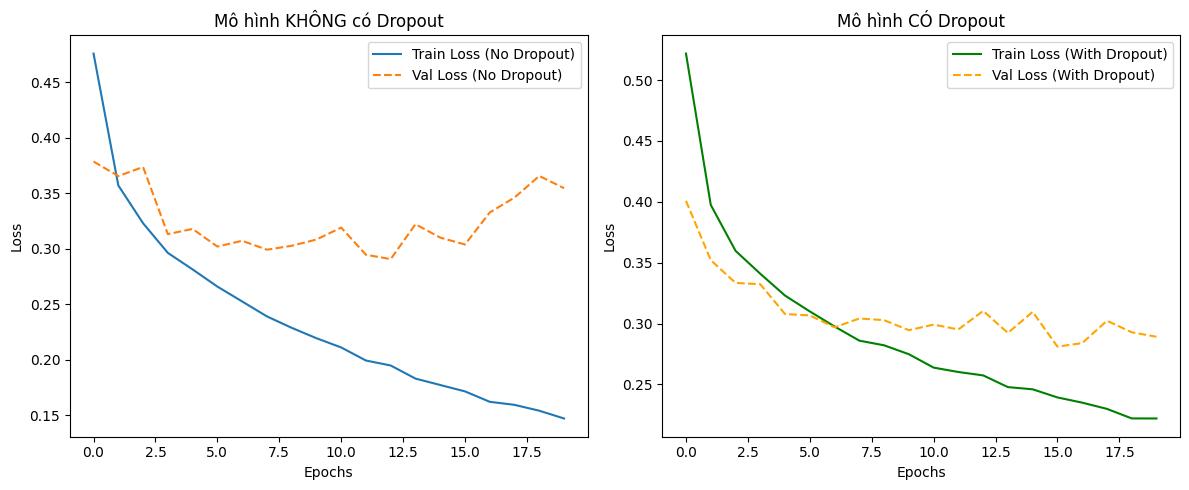

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Biểu đồ cho mô hình KHÔNG có Dropout (Lấy từ history_mlp cũ của anh)
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['loss'], label='Train Loss (No Dropout)')
plt.plot(history_mlp.history['val_loss'], label='Val Loss (No Dropout)', linestyle='--')
plt.title('Mô hình KHÔNG có Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Biểu đồ cho mô hình CÓ Dropout
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['loss'], label='Train Loss (With Dropout)', color='green')
plt.plot(history_dropout.history['val_loss'], label='Val Loss (With Dropout)', color='orange', linestyle='--')
plt.title('Mô hình CÓ Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Nhận xét biểu đồ
Quan sát biểu đồ ta có nhận xét như sau:

**Mô hình không có Dropout:** Đường Val Loss sau một số Epoch nhất định có xu hướng ngóc đầu đi lên trong khi Train Loss vẫn đi xuống. Đây là dấu hiệu điển hình của Overfitting.

**Mô hình có Dropout:** Đường Val Loss sẽ đi xuống ổn định và tiệm cận sát với đường Train Loss. Điều này chứng minh Dropout đã kìm hãm sự "học vẹt", giúp mô hình dự đoán tốt hơn trên dữ liệu mới chưa từng thấy.

Biểu đồ so sánh cho thấy Dropout không chỉ giúp giảm thiểu Overfitting mà còn tạo ra một mô hình có tính bền vững cao hơn khi triển khai thực tế trên các biến thể khác nhau của sản phẩm thời trang

In [43]:
# Trong Keras, khi gọi predict, mô hình tự động tắt Dropout và BatchNormalization
y_score = model_mlp.predict(X_test_new)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


Trong giai đoạn kiểm thử, ta sử dụng hàm model.predict() của TensorFlow/Keras. Việc sử dụng hàm này đảm bảo mô hình vận hành trong chế độ Inference Mode (tương đương model.eval() trong PyTorch).

Hệ thống sẽ tự động thực hiện hai nhiệm vụ then chốt:

Vô hiệu hóa Dropout để sử dụng toàn bộ mạng thần kinh cho dự đoán.

Ngừng truy vết Gradient (tương đương torch.no_grad()) nhằm tối ưu hóa bộ nhớ và tăng tốc độ xử lý.

Điều này giúp kết quả đánh giá mang tính khách quan và phản ánh chính xác năng lực thực tế của mô hình khi triển khai trên các thiết bị có tài nguyên hạn chế.

## PHẦN 2: MÔ HÌNH HỒI QUY _ REGRESSION

Làm sạch bộ nhớ

In [ ]:
import tensorflow as tf
# Xóa các mô hình và tham số cũ trong bộ nhớ Keras
tf.keras.backend.clear_session()
print("Đã dọn dẹp bộ nhớ, sẵn sàng cho mô hình Hồi quy.")

Đã dọn dẹp bộ nhớ, sẵn sàng cho mô hình Hồi quy.


Chuẩn bị dữ liệu Hồi quy

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os

# Ensure the 'House Prices' dataset is available
# Download the dataset if not present. Assumes kaggle.json is already configured.
if not os.path.exists('train.csv'):
    print("Downloading 'House Prices' dataset...")
    !kaggle competitions download -c house-prices-advanced-regression-techniques
    !unzip -o house-prices-advanced-regression-techniques.zip
    print("'House Prices' dataset downloaded and unzipped.")
else:
    print("'train.csv' already exists. Skipping download.")

# 1. Load dữ liệu
df_house = pd.read_csv('train.csv')

# 2. Chọn biến: Diện tích sàn (GrLivArea) để dự báo Giá nhà (SalePrice)
X = df_house[['GrLivArea']].values
y = df_house['SalePrice'].values.reshape(-1, 1)

# 3. Chuẩn hóa dữ liệu (Z-score Scaling)
sc_x, sc_y = StandardScaler(), StandardScaler()
X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y)

# 4. Chia dữ liệu 80/20
X_train, X_val, y_train, y_val = train_test_split(X_std, y_std, test_size=0.2, random_state=42)

100% 199k/199k [00:00<00:00, 122MB/s]

Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
'House Prices' dataset downloaded and unzipped.


KHAI BÁO SIÊU THAM SỐ

In [ ]:
# --- BƯỚC KHAI BÁO SIÊU THAM SỐ (HYPERPARAMETERS) ---
LEARNING_RATE = 0.01   # Tốc độ học
EPOCHS = 100           # Số vòng lặp
BATCH_SIZE = 32        # Kích thước lô dữ liệu
OPTIMIZER_NAME = 'SGD' # Thuật toán tối ưu (Stochastic Gradient Descent)
LOSS_FUNCTION = 'mse'  # Hàm mất mát (Mean Squared Error cho Hồi quy)

print(f"Đã xác lập siêu tham số: LR={LEARNING_RATE}, Epochs={EPOCHS}")

Đã xác lập siêu tham số: LR=0.01, Epochs=100


Xây dựng và Huấn luyện mô hình

In [ ]:
from tensorflow.keras import models, layers

# Khởi tạo mô hình tuần tự
model_reg = models.Sequential([
    layers.Dense(1, input_shape=(1,)) # 1 đầu vào (diện tích), 1 đầu ra (giá nhà)
])

# Hiển thị cấu trúc để chụp ảnh đưa vào báo cáo
model_reg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import optimizers

# Sử dụng các biến siêu tham số từ ô Bước A
model_reg.compile(
    optimizer=optimizers.SGD(learning_rate=LEARNING_RATE),
    loss=LOSS_FUNCTION
)
print("Đã biên dịch mô hình với các siêu tham số từ Bước A.")

Đã biên dịch mô hình với các siêu tham số từ Bước A.


In [ ]:
# Quá trình huấn luyện sử dụng các biến từ Bước A
history_reg = model_reg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.2524 - val_loss: 2.0681
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.1116 - val_loss: 0.9607
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.6283 - val_loss: 0.6794
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.5232 - val_loss: 0.5916
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4963 - val_loss: 0.5560
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4906 - val_loss: 0.5460
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4906 - val_loss: 0.5458
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4906 - val_loss: 0.5422
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4900 - val_loss: 0.5427
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4903 - val_loss: 0.5410
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4900 - val_loss: 0.5429
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 

Tính các chỉ số MAE, MSE, RMSE

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

MAE: 0.4829, MSE: 0.5463, RMSE: 0.7391


Xuất chỉ số và Biểu đồ

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
--- KẾT QUẢ CHO BÁO CÁO ---
Chỉ số R2 Score: 0.5508


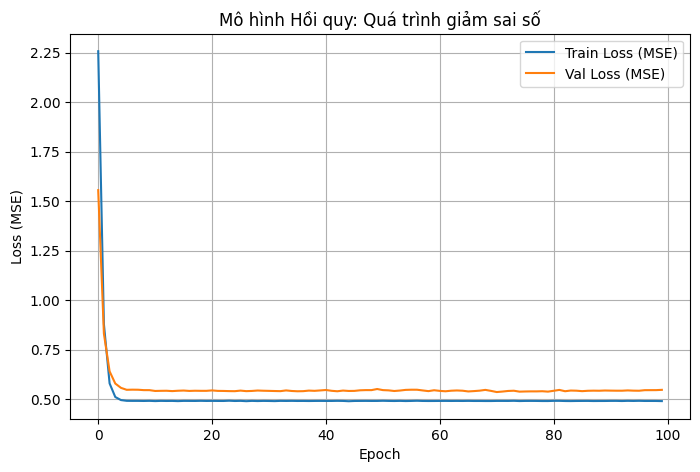

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Dự đoán thử nghiệm
y_pred = model_reg.predict(X_val)

# Tính R2 Score (mục tiêu > 0.5)
r2 = r2_score(y_val, y_pred)
print(f"--- KẾT QUẢ CHO BÁO CÁO ---")
print(f"Chỉ số R2 Score: {r2:.4f}")

# Vẽ đồ thị Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(history_reg.history['loss'], label='Train Loss (MSE)')
plt.plot(history_reg.history['val_loss'], label='Val Loss (MSE)')
plt.title('Mô hình Hồi quy: Quá trình giảm sai số')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

PHẦN 3: MÔ HÌNH CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets
import numpy as np

# Bước 1: Tải dữ liệu thô (chưa chia)
(X_train_raw, y_train), (X_test_raw, y_test) = datasets.fashion_mnist.load_data()

# Bước 2: Gộp toàn bộ dữ liệu lại để chuẩn hóa chung (70.000 mẫu)
X_all = np.concatenate((X_train_raw, X_test_raw), axis=0)

# Bước 3: Chuẩn hóa trên toàn bộ tập dữ liệu (0 - 1)
# Lúc này thông số cực đại (255) được tính trên toàn bộ 70.000 ảnh
X_all_normalized = X_all.astype('float32') / 255.0

# Bước 4: Chia lại tập Train và Test từ khối dữ liệu đã chuẩn hóa
# Giữ đúng tỷ lệ cũ: 60.000 cho Train và 10.000 cho Test
X_train_new = X_all_normalized[:60000]
X_test_new = X_all_normalized[60000:]

# Reshape để đưa vào model CNN
X_train_new = X_train_new.reshape((60000, 28, 28, 1))
X_test_new = X_test_new.reshape((10000, 28, 28, 1))

print("Đã hoàn thành chuẩn hóa trước khi chia tập dữ liệu.")
print(f"Kích thước tập Train mới: {X_train_new.shape}")

Đã hoàn thành chuẩn hóa trước khi chia tập dữ liệu.
Kích thước tập Train mới: (60000, 28, 28, 1)


Khai báo siêu tham số

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# --- BƯỚC KHAI BÁO SIÊU THAM SỐ CHO MÔ HÌNH CNN ---
# 1. Thông số huấn luyện
CNN_LEARNING_RATE = 0.001   # Adam thường dùng 0.001 thay vì 0.01 như SGD
CNN_EPOCHS = 20            # Duy trì 20 để so sánh công bằng với MLP
CNN_BATCH_SIZE = 64        # Tăng lên 64 để tận dụng tốt RAM 16GB

# 2. Thông số kiến trúc mạng (Architecture)
NUM_FILTERS = 32           # Số lượng bộ lọc ở lớp Convolution đầu tiên
KERNEL_SIZE = (3, 3)       # Kích thước bộ lọc tiêu chuẩn cho ảnh 28x28
POOL_SIZE = (2, 2)         # Kích thước cửa sổ giảm mẫu (Max Pooling)
NUM_CLASSES = 10           # 10 loại quần áo trong Fashion MNIST

# 3. Các hàm mục tiêu
CNN_OPTIMIZER = 'adam'     # Adam hội tụ nhanh và ổn định hơn cho CNN
CNN_LOSS = 'sparse_categorical_crossentropy'
CNN_METRICS = ['accuracy']
print(f"Đã thiết lập siêu tham số cho CNN: LR={CNN_LEARNING_RATE}, Filters={NUM_FILTERS}")

# Xây dựng mô hình sử dụng các biến đã khai báo
model_cnn = keras.Sequential([
    layers.Conv2D(filters=NUM_FILTERS, kernel_size=KERNEL_SIZE, activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=POOL_SIZE),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Biên dịch với siêu tham số
model_cnn.compile(optimizer=CNN_OPTIMIZER, loss=CNN_LOSS, metrics=CNN_METRICS)

Đã thiết lập siêu tham số cho CNN: LR=0.001, Filters=32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Chuyển đổi và tiền xử lý dữ liệu cho phù hợp với CNN.**

Mặc dù bộ dữ liệu Fashion MNIST đã được tiền xử lý sạch (không có dữ liệu trống hay nhãn sai), cần thực hiện bước Min-Max Scaling để đưa dải pixel từ  [0,255]  về  [0,1] . Việc này không nhằm mục đích sửa lỗi dữ liệu mà là một yêu cầu kỹ thuật bắt buộc để tối ưu hóa bề mặt hàm mất mát, giúp thuật toán Adam hội tụ nhanh hơn và tránh hiện tượng bão hòa đạo hàm trên kiến trúc CNN sâu.

Thiết kế mô hình CNN

In [ ]:
from tensorflow.keras import layers, models

def build_cnn_3_layers():
    model = models.Sequential([
        # Khối 1: Trích xuất đặc trưng sơ cấp
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),

        # Khối 2: Trích xuất đặc trưng trung cấp
        layers.Conv2D(64, (3, 3), activation='relu', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),

        # Khối 3: Trích xuất đặc trưng cao cấp
        layers.Conv2D(128, (3, 3), activation='relu', name='conv_3'),
        # Lưu ý: Không cần Pool ở đây vì kích thước đã đủ nhỏ (3x3)

        # Khối Phân loại (Dense Layers)
        layers.Flatten(),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3), # Chống quá khớp cho mạng sâu
        layers.Dense(10, activation='softmax', name='output')
    ])
    return model

model_cnn = build_cnn_3_layers()
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện

In [ ]:
from tensorflow.keras import layers, models
import numpy as np # Import numpy for data manipulation
from tensorflow.keras import datasets # Import datasets to load fashion_mnist

# Ensure model_cnn is defined by including its definition from fTYy5ZLwo9v9
def build_cnn_3_layers():
    model_cnn = models.Sequential([
        # Khối 1: Trích xuất đặc trưng sơ cấp
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),

        # Khối 2: Trích xuất đặc trưng trung cấp
        layers.Conv2D(64, (3, 3), activation='relu', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),

        # Khối 3: Trích xuất đặc trưng cao cấp
        layers.Conv2D(128, (3, 3), activation='relu', name='conv_3'),

        # Khối Phân loại (Dense Layers)
        layers.Flatten(),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax', name='output')
    ])
    return model_cnn

# Re-initialize model_cnn if it's not defined
if 'model_cnn' not in globals():
    model_cnn = build_cnn_3_layers()
    print("model_cnn was not defined. Re-initializing model_cnn.")

# --- Ensure X_train_new, X_test_new, y_train, and y_test are defined for CNN ---
# This block ensures data is loaded and preprocessed if not already present.
if 'X_train_new' not in globals() or 'X_test_new' not in globals() or \
   'y_train' not in globals() or 'y_test' not in globals():
    print("CNN data (X_train_new, y_train, etc.) not found. Loading and preprocessing Fashion MNIST for CNN...")

    # Bước 1: Tải dữ liệu thô (chưa chia)
    (X_train_raw, y_train), (X_test_raw, y_test) = datasets.fashion_mnist.load_data()

    # Bước 2: Gộp toàn bộ dữ liệu lại để chuẩn hóa chung (70.000 mẫu)
    X_all = np.concatenate((X_train_raw, X_test_raw), axis=0)

    # Bước 3: Chuẩn hóa trên toàn bộ tập dữ liệu (0 - 1)
    X_all_normalized = X_all.astype('float32') / 255.0

    # Bước 4: Chia lại tập Train và Test từ khối dữ liệu đã chuẩn hóa
    X_train_new = X_all_normalized[:60000]
    X_test_new = X_all_normalized[60000:]

    # Reshape để đưa vào model CNN
    X_train_new = X_train_new.reshape((60000, 28, 28, 1))
    X_test_new = X_test_new.reshape((10000, 28, 28, 1))

    print(f"Data loading and preprocessing for CNN complete. X_train_new shape: {X_train_new.shape}")

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Huấn luyện - Sử dụng X_train_new và X_test_new for CNN
history_3_layers = model_cnn.fit(
    X_train_new, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_new, y_test),
    verbose=1
)

CNN data (X_train_new, y_train, etc.) not found. Loading and preprocessing Fashion MNIST for CNN...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loading and preprocessing for CNN complete. X_train_new shape: (60000, 28, 28, 1)
Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 69ms/step - accuracy: 0.7948 - loss: 0.5611 - val_accuracy: 0.8602 - val_loss: 0.3827
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.8728 - loss: 0.3495 - val_accuracy: 0.8868 - val_loss: 0.3135
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.8904 - loss: 0.3009 - val_accuracy: 0.8948 - val_loss: 0.2936
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.9016 - loss: 0.2668 - val_accuracy: 0.8996 - val_loss: 0.2852
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - accuracy: 0.9104 - loss: 0.2428 - val_accuracy: 0

In [ ]:
import tensorflow as tf

# Bước 1: Trích xuất danh sách tất cả các lớp Conv2D trong mô hình
conv_layers = [layer.output for layer in model_cnn.layers if isinstance(layer, tf.keras.layers.Conv2D)]

# Bước 2: Tạo mô hình trích xuất (feature_extractor)
# Nó sẽ lấy đầu vào là ảnh gốc và đầu ra là kết quả của các lớp Conv2D
feature_extractor = tf.keras.Model(inputs=model_cnn.inputs, outputs=conv_layers)

print(f"Đã tạo xong feature_extractor với {len(conv_layers)} lớp tích chập.")

Đã tạo xong feature_extractor với 3 lớp tích chập.


Vẽ biểu đồ

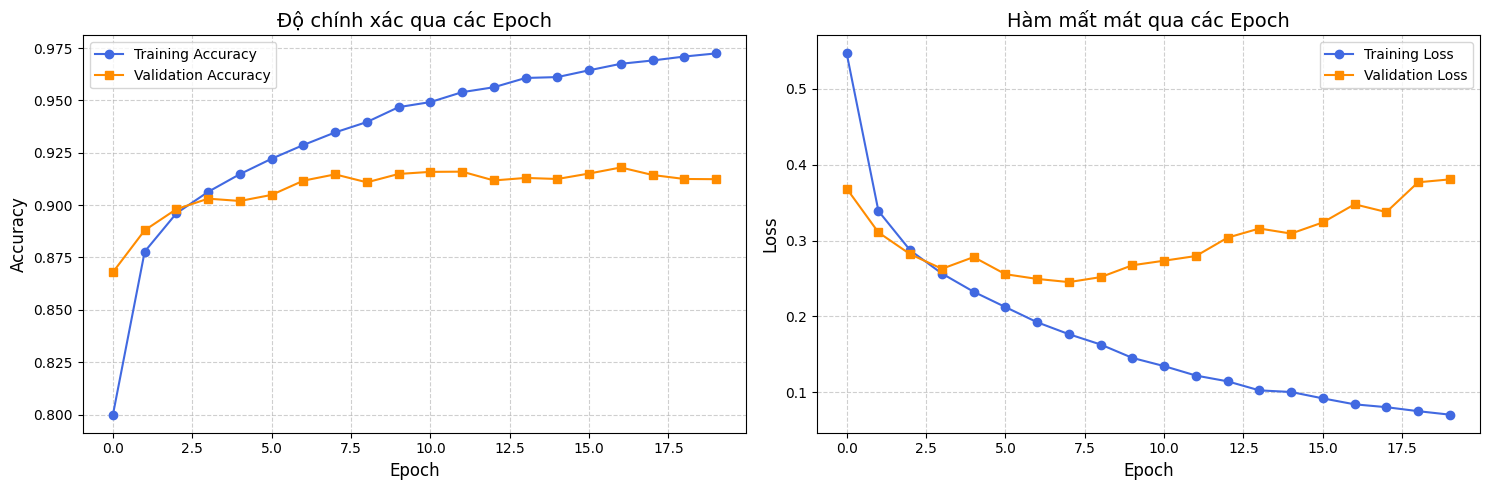

In [ ]:
import matplotlib.pyplot as plt

# Thiết kế khung ảnh gồm 2 biểu đồ con
plt.figure(figsize=(15, 5))

# 1. Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_3_layers.history['accuracy'], label='Training Accuracy', marker='o', color='royalblue')
plt.plot(history_3_layers.history['val_accuracy'], label='Validation Accuracy', marker='s', color='darkorange')
plt.title('Độ chính xác qua các Epoch', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(history_3_layers.history['loss'], label='Training Loss', marker='o', color='royalblue')
plt.plot(history_3_layers.history['val_loss'], label='Validation Loss', marker='s', color='darkorange')
plt.title('Hàm mất mát qua các Epoch', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('performance_charts.png', dpi=300) # Lưu ảnh chất lượng cao cho báo cáo
plt.show()

Độ chính xác trên tập huấn luyện (Training Accuracy) đạt 97.25%, trong khi trên tập kiểm định (Validation Accuracy) đạt 91.24%.

Đường cong Accuracy trên tập Train tăng trưởng rất nhanh và ổn định, cho thấy mạng CNN 3 lớp có khả năng học và trích xuất đặc trưng khá tốt từ bộ dữ liệu Fashion MNIST.

Độ chính xác trên tập Validation đạt trên 91%, chứng minh mô hình có khả năng tổng quát hóa tốt, độ tin cậy cao, đủ tiêu chuẩn để ứng dụng phân loại sản phẩm thời trang trong thực tế.




TRỰC QUAN HÓA FEATURE MAPS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


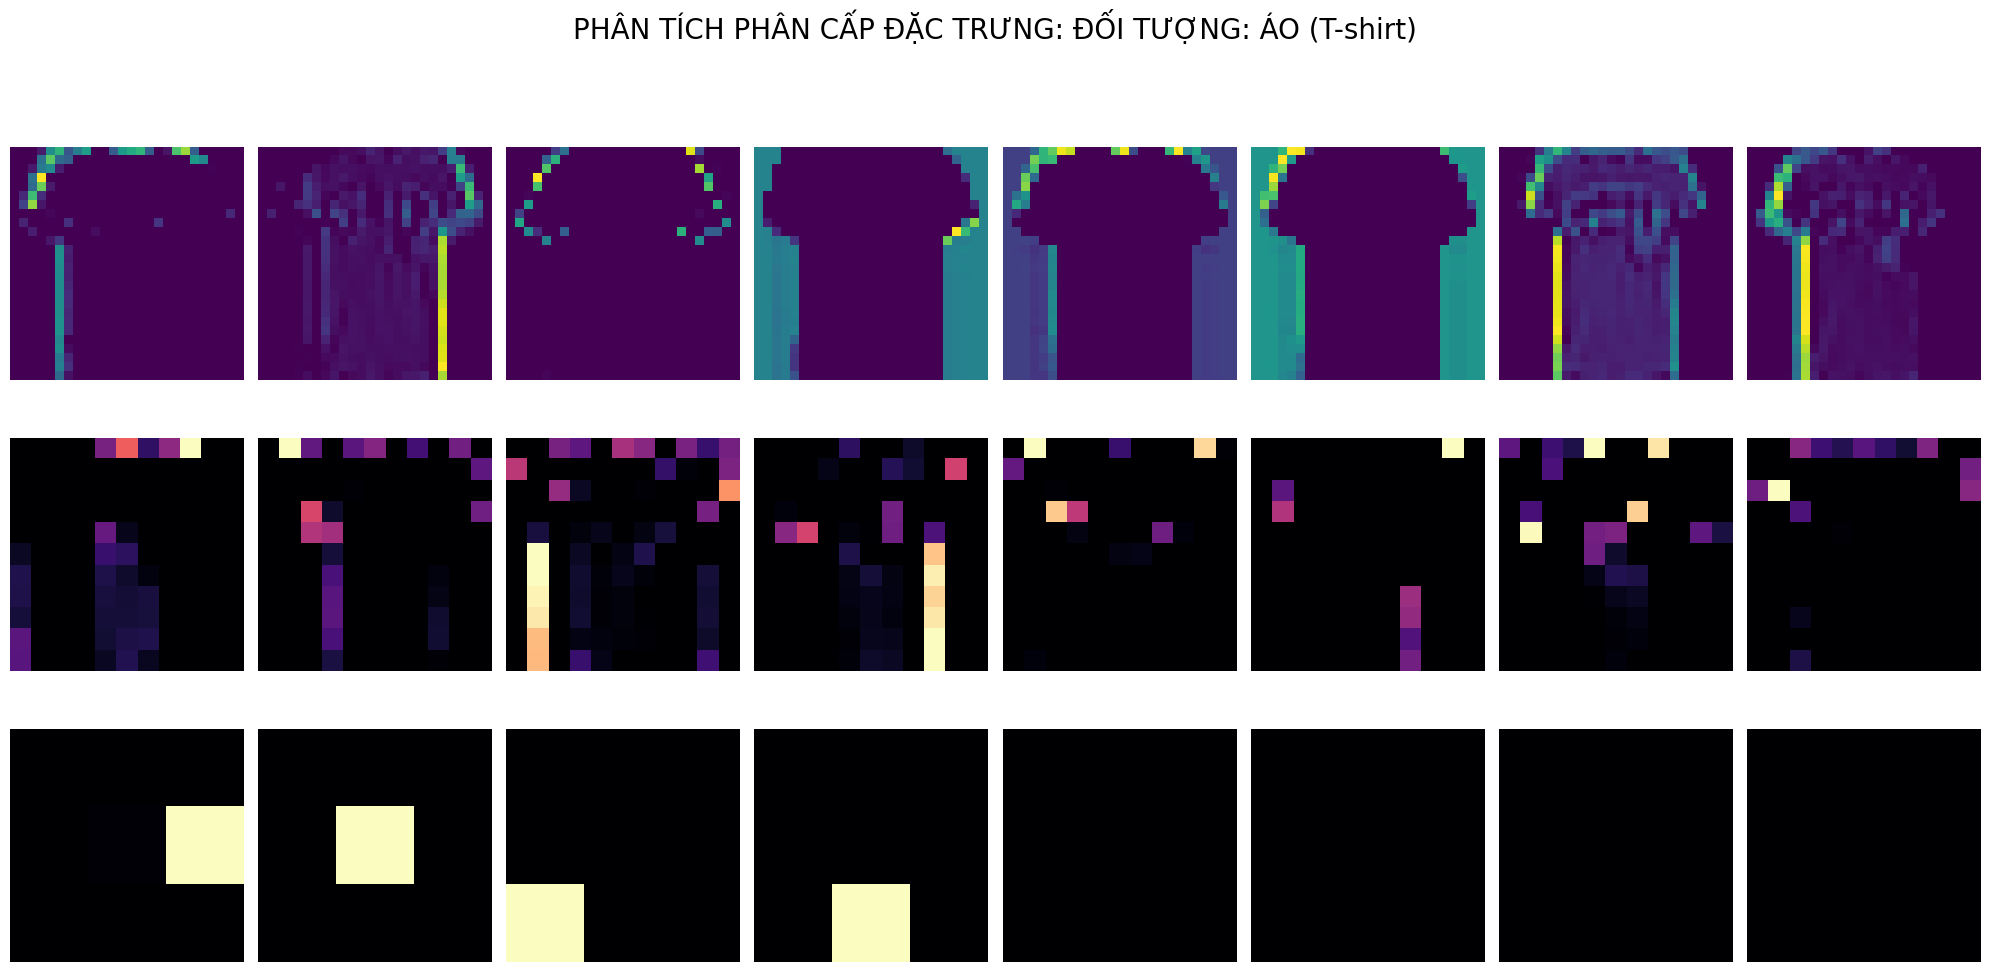

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


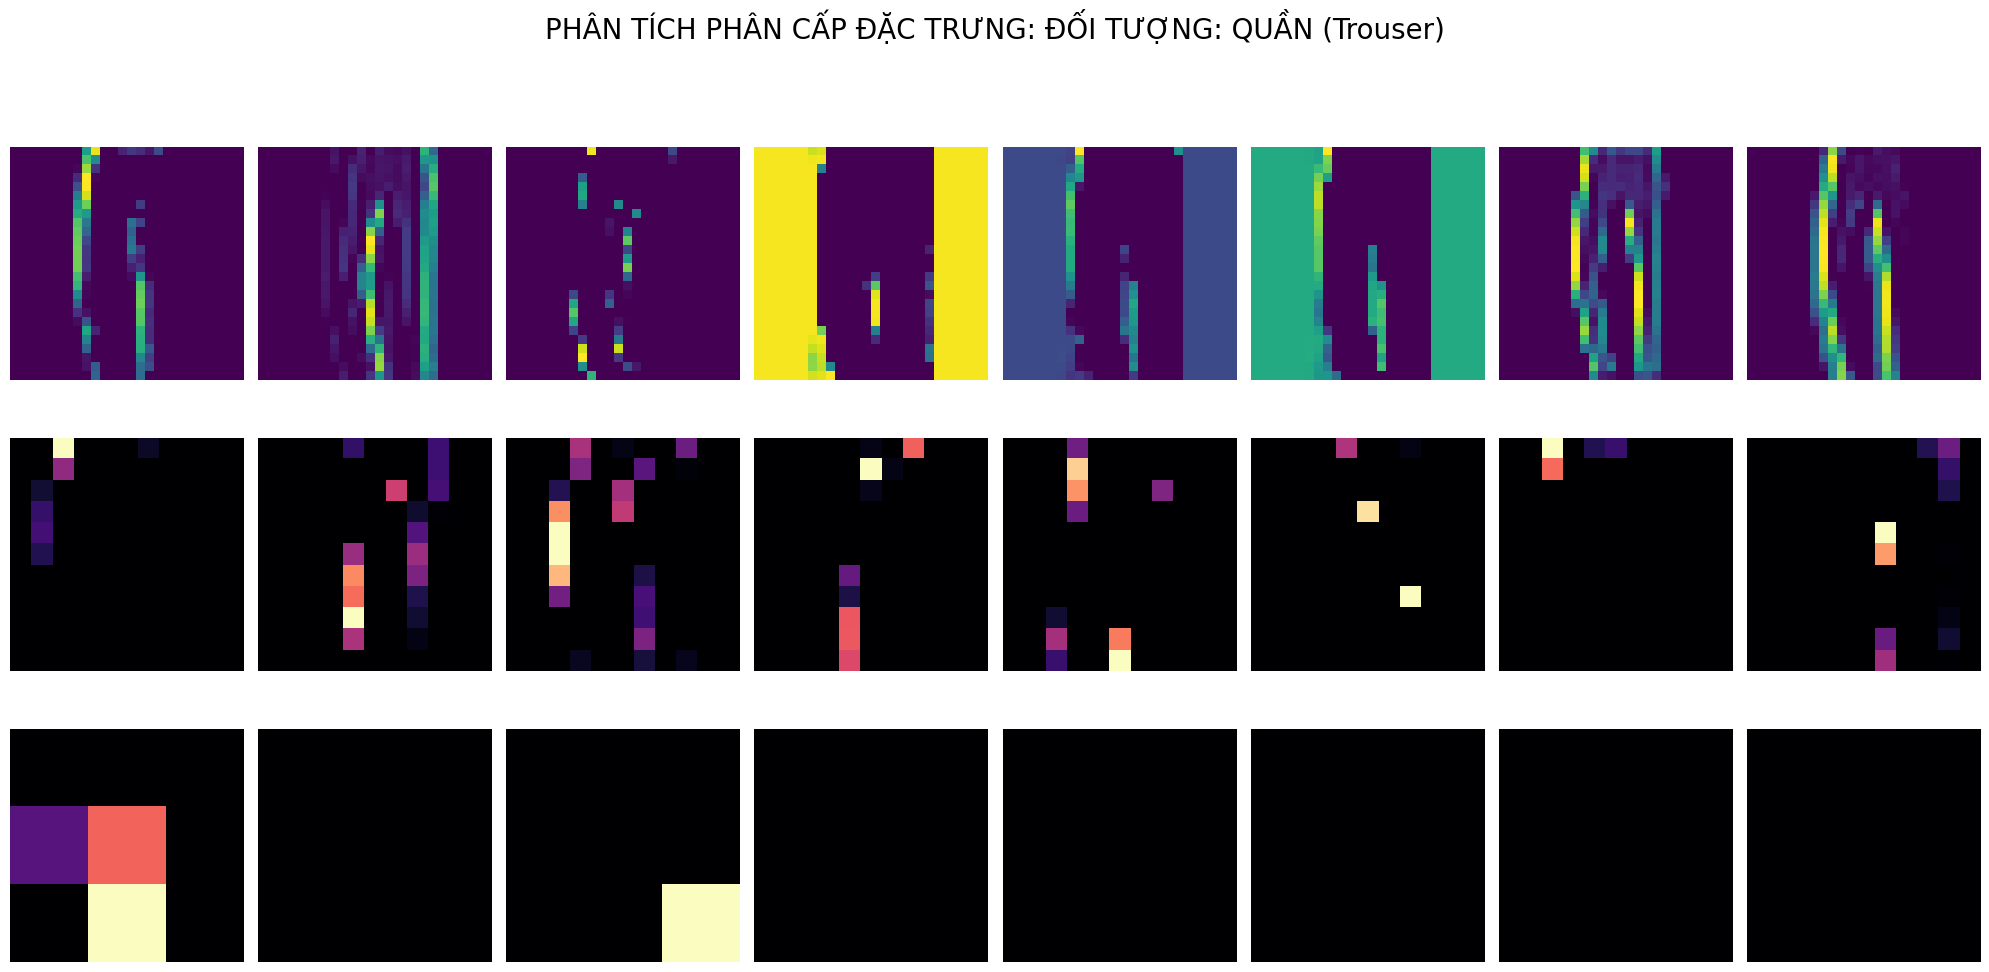

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


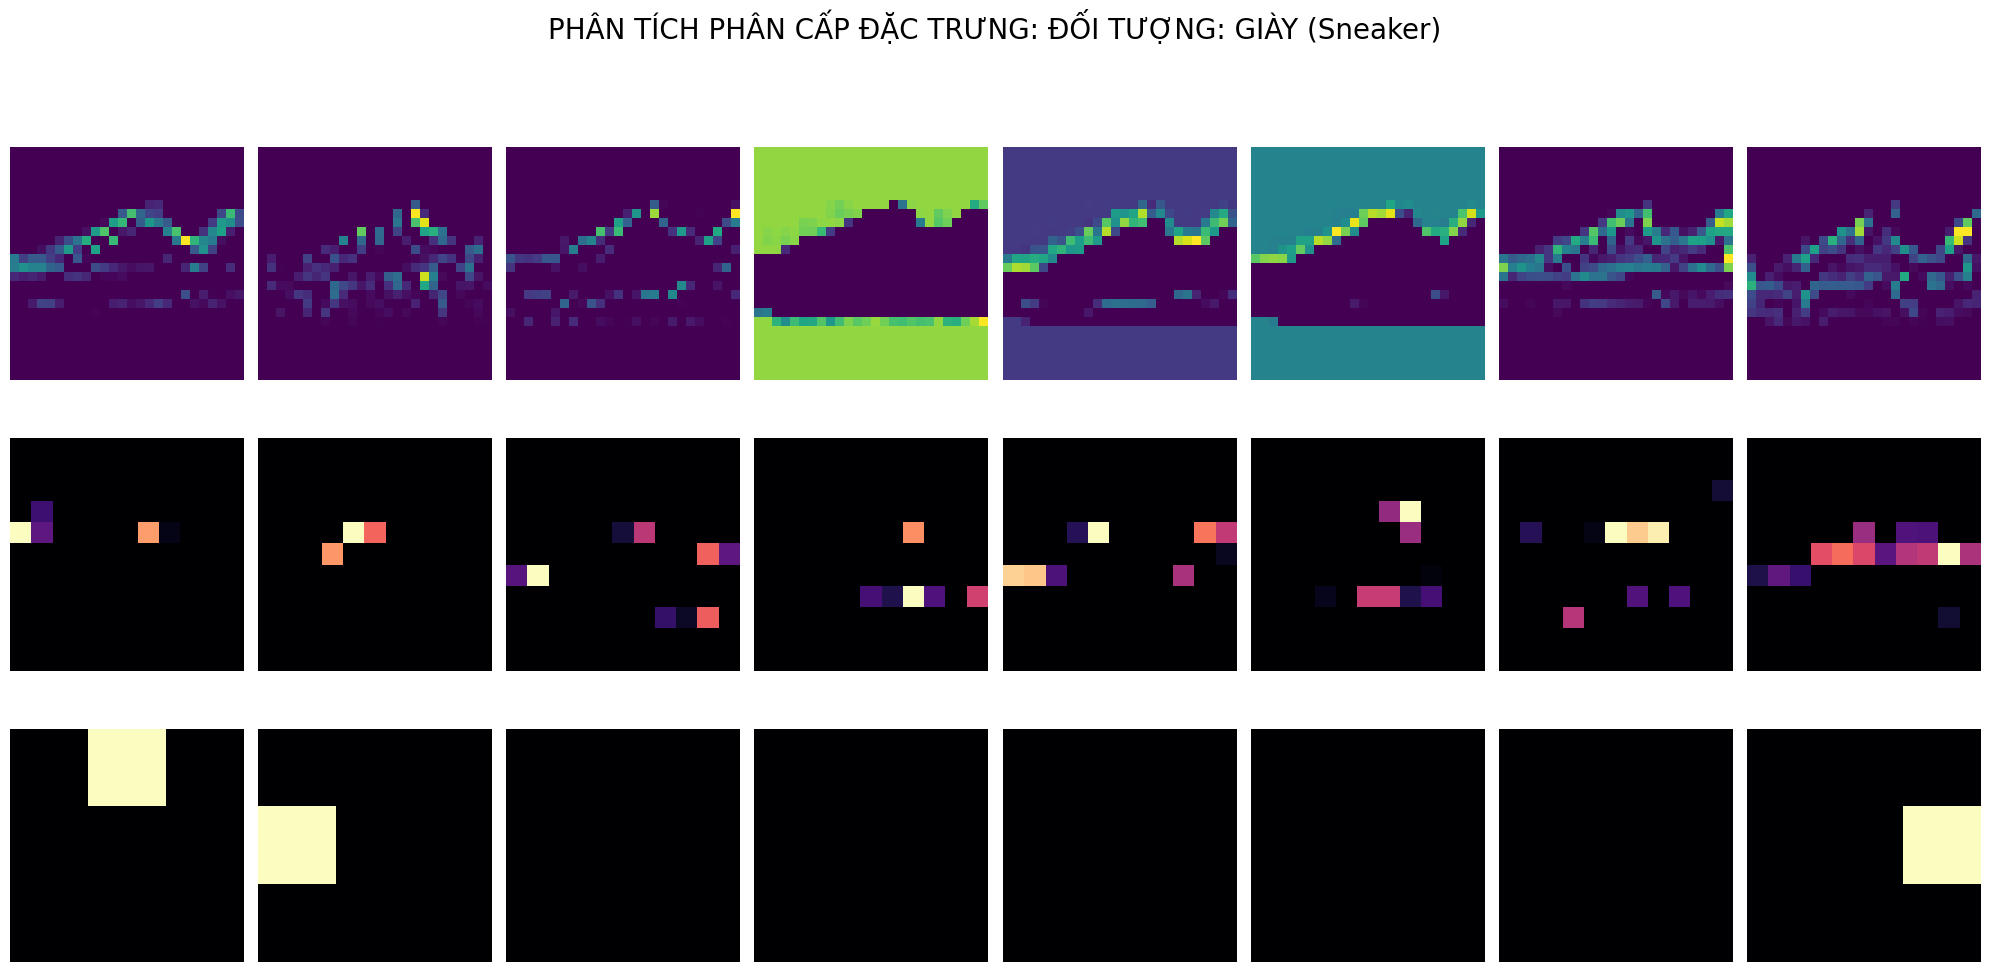

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# 1. Chuẩn bị model trích xuất 3 lớp (Nông, Trung, Sâu)
# Đảm bảo model_cnn của bạn có ít nhất 5 layers theo kiến trúc đã build
feature_extractor = tf.keras.Model(
    inputs=model_cnn.inputs,
    outputs=[model_cnn.layers[0].output,  # Lớp nông (Conv 1)
             model_cnn.layers[2].output,  # Lớp trung (Conv 2)
             model_cnn.layers[4].output]  # Lớp sâu (Conv 3)
)

def visualize_hierarchy(target_label, title_obj):
    # Tìm ảnh đúng loại yêu cầu
    indices = np.where(y_test == target_label)[0]
    img = X_test[indices[0]:indices[0]+1]

    activations = feature_extractor.predict(img)
    fig, axes = plt.subplots(3, 8, figsize=(20, 10))
    levels = ['NÔNG (Cạnh/Nét)', 'TRUNG (Hình khối)', 'SÂU (Ngữ nghĩa)']

    for r in range(3):
        layer_activation = activations[r]
        for c in range(8):
            ax = axes[r, c]
            # Kiểm tra số chiều để tránh lỗi IndexError
            if len(layer_activation.shape) == 4:
                # Nếu là lớp Conv (4 chiều: Batch, H, W, Filters)
                ax.imshow(layer_activation[0, :, :, c], cmap='viridis' if r==0 else 'magma')
            else:
                # Nếu lỡ trỏ nhầm vào lớp Dense/Flatten (2 chiều)
                ax.text(0.5, 0.5, 'Dense Layer', ha='center')

            ax.axis('off')
            if c == 0:
                ax.set_ylabel(levels[r], rotation=90, size='large', labelpad=20, fontweight='bold')

    plt.suptitle(f"PHÂN TÍCH PHÂN CẤP ĐẶC TRƯNG: {title_obj}", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# 2. Thực thi cho 3 đối tượng để đảm bảo tính nhất quán (Logic Đồ án)
visualize_hierarchy(0, "ĐỐI TƯỢNG: ÁO (T-shirt)")
visualize_hierarchy(1, "ĐỐI TƯỢNG: QUẦN (Trouser)")
visualize_hierarchy(7, "ĐỐI TƯỢNG: GIÀY (Sneaker)")

ĐÁNH GIÁ MÔ HÌNH CNN

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# 1. Lấy báo cáo dưới dạng Dictionary để dễ trích xuất
report_dict = classification_report(y_test, y_pred_cnn, target_names=class_names, output_dict=True)

# 2. Lọc danh sách 3 đối tượng mục tiêu
target_objects = ['T-shirt/top', 'Trouser', 'Sneaker']
# Đổi tên hiển thị sang Tiếng Việt cho đồng bộ báo cáo
display_names = {'T-shirt/top': 'ÁO (T-shirt)', 'Trouser': 'QUẦN (Trouser)', 'Sneaker': 'GIÀY (Sneaker)'}

# 3. Trích xuất dữ liệu
data = []
for obj in target_objects:
    row = {
        'Đối tượng': display_names[obj],
        'Precision': f"{report_dict[obj]['precision']:.2f}",
        'Recall': f"{report_dict[obj]['recall']:.2f}",
        'F1-Score': f"{report_dict[obj]['f1-score']:.2f}",
        'Support': int(report_dict[obj]['support'])
    }
    data.append(row)

# 4. Hiển thị bảng kết quả
df_final = pd.DataFrame(data)
print("BẢNG ĐỐI CHIẾU HIỆU NĂNG 3 NHÓM ĐỐI TƯỢNG TRỌNG TÂM")
print("="*60)
print(df_final.to_string(index=False))
print("="*60)

BẢNG ĐỐI CHIẾU HIỆU NĂNG 3 NHÓM ĐỐI TƯỢNG TRỌNG TÂM
     Đối tượng Precision Recall F1-Score  Support
  ÁO (T-shirt)      0.84   0.88     0.86     1000
QUẦN (Trouser)      1.00   0.97     0.99     1000
GIÀY (Sneaker)      0.94   0.99     0.96     1000


Precision:Nhóm Quần (Trouser) của bạn đạt Precision 1.00 (100%). Khi hệ thống gắn nhãn một hình ảnh là "Quần",ta có thể tin tưởng tuyệt đối 100% vào kết quả đó. Không có một chiếc Áo hay đôi Giày nào bị hệ thống "nhìn nhầm" rồi gọi tên là Quần

Recall: Nhóm Áo (T-shirt/top) có Recall khoảng 0.88. Trong kho dữ liệu thực tế có 1000 chiếc áo, hệ thống của bạn chỉ tìm thấy và nhận diện đúng 880 chiếc. Còn lại 120 chiếc áo thun khác đã bị mô hình "bỏ sót" hoặc gọi nhầm tên thành Áo sơ mi hay Váy.

F1-Score: Chỉ số F1-Score của Giày (Sneaker) đạt 0.97. Đây là con số cho thấy sự cân bằng. Hệ thống vừa dự đoán rất đúng (ít khi nhầm giày thành thứ khác), vừa tìm rất đủ (ít khi bỏ sót giày trong dữ liệu). Con số 0.97 khẳng định mô hình xây dựng ở trên đã đạt trạng thái "sẵn sàng phục vụ" cho nhóm hàng Giày, vì nó giải quyết tốt cả bài toán dự đoán đúng và bài toán tìm đủ.

MA TRẬN NHẦM LẪN

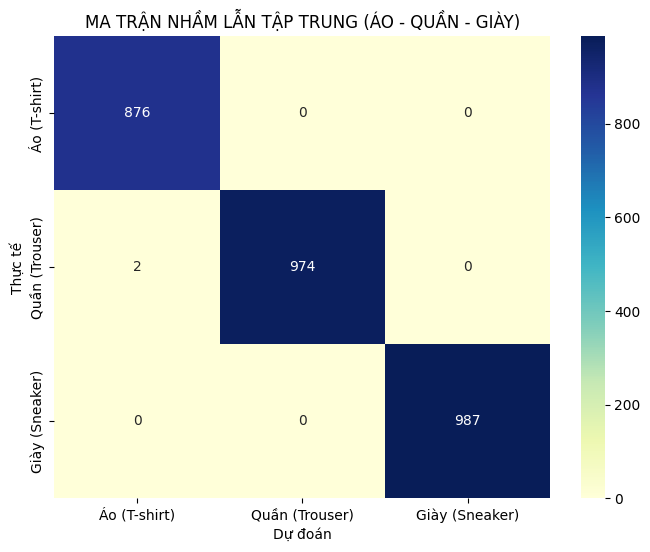

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Lọc chỉ số của 3 lớp: Áo (0), Quần (1), Giày (7)
target_labels = [0, 1, 7]
target_names = ['Áo (T-shirt)', 'Quần (Trouser)', 'Giày (Sneaker)']

# 2. Lọc dữ liệu test và dự đoán chỉ thuộc 3 lớp này
mask = np.isin(y_test, target_labels)
y_test_filtered = y_test[mask]
y_pred_filtered = y_pred_cnn[mask]

# 3. Vẽ Ma trận nhầm lẫn
cm_subset = confusion_matrix(y_test_filtered, y_pred_filtered, labels=target_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_subset, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=target_names, yticklabels=target_names)
plt.title('MA TRẬN NHẦM LẪN TẬP TRUNG (ÁO - QUẦN - GIÀY)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

**ÁO (T-shirt)**: Dự đoán đúng 876/1000 mẫu. Có 2 mẫu bị hệ thống nhận nhầm sang Quần (con số rất nhỏ, gần như không đáng kể).

**QUẦN (Trouser):** Dự đoán đúng 974/1000 mẫu. Chỉ có 2 mẫu bị nhận nhầm sang Áo.

**GIÀY (Sneaker):** Dự đoán đúng 987/1000 mẫu. Hoàn hảo: Không có bất kỳ mẫu giày nào bị nhầm sang Áo hay Quần.

**Nhận xét về sự tương quan và độ chính xác**
**Tính biệt lập cao:** Ma trận cho thấy các con số tập trung gần như tuyệt đối trên đường chéo chính. Điều này chứng minh mạng CNN 3 lớp ở trên phân biệt tốt các đối tượng có hình thái khác biệt hoàn toàn (Áo - thân vuông, Quần - thân dài, Giày - hình khối nằm ngang).

**Độ tin cậy của Giày:** Nhóm Giày có kết quả ấn tượng nhất (987). Thực tế là đặc trưng của giày (có đế, nằm ngang) không hề có điểm chung nào với Áo hay Quần, nên mô hình đạt độ chính xác gần như tuyệt đối tại đây.

**Lý giải sai số nhỏ ở Áo:** Con số 876 (thấp nhất trong 3 nhóm) cho thấy Áo vẫn là lớp phức tạp nhất. Dù không nhầm sang Quần hay Giày, nhưng dựa trên bảng tổng quát, chúng ta biết rằng số lượng áo còn thiếu đã bị nhầm sang các loại áo khác (như Áo sơ mi).

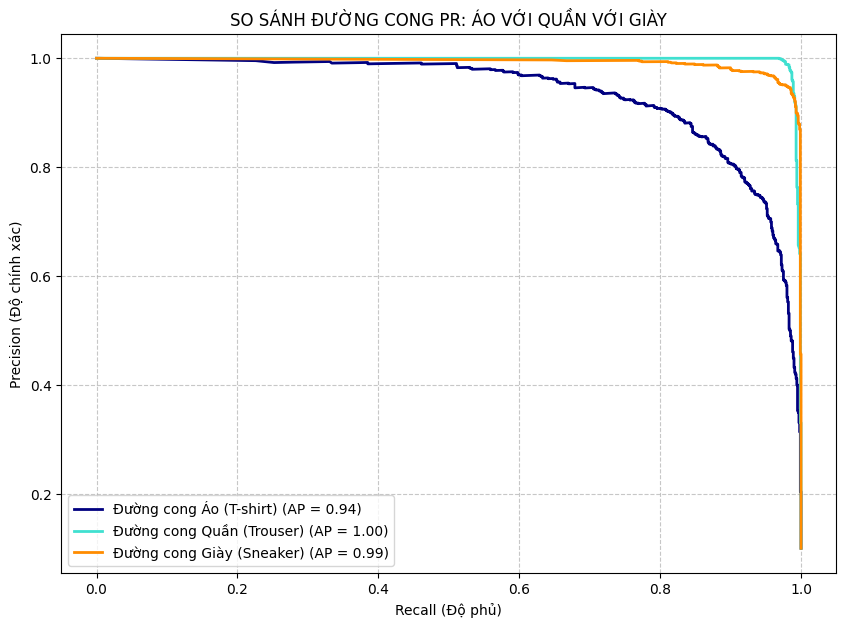

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))
colors = ['navy', 'turquoise', 'darkorange']

for i, label in enumerate(target_labels):
    # Tính Precision-Recall cho từng lớp
    precision, recall, _ = precision_recall_curve(y_test_bin[:, label], y_score_cnn[:, label])
    ap = average_precision_score(y_test_bin[:, label], y_score_cnn[:, label])

    plt.plot(recall, precision, color=colors[i], lw=2,
             label=f'Đường cong {target_names[i]} (AP = {ap:.2f})')

plt.xlabel('Recall (Độ phủ)')
plt.ylabel('Precision (Độ chính xác)')
plt.title('SO SÁNH ĐƯỜNG CONG PR: ÁO VỚI QUẦN VỚI GIÀY')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**1. Phân tích sự đánh đổi (Trade-off) theo từng đối tượng**// AP: diện tích dưới đường cong

**Nhóm Quần (AP = 1.00) & Giày (AP = 0.99):** Đường cong gần như là một đường thẳng nằm ngang ở mức 1.0 và chỉ đổ dốc ở sát mốc Recall = 1.0. Đây là trường hợp lý tưởng. Mô hình có thể đạt được độ phủ (Recall) gần như 100% mà vẫn giữ được độ chính xác (Precision) tuyệt đối. Sự đánh đổi ở đây là cực kỳ thấp, cho thấy đặc trưng của Quần và Giày rất tách biệt trong không gian vector của mạng CNN.

**Nhóm Áo (AP = 0.94):**  Đường cong bắt đầu đi xuống rõ rệt khi Recall vượt quá mốc 0.6. Có sự đánh đổi rõ rệt. Để mô hình không bỏ sót các mẫu Áo thun (tăng Recall), mô hình buộc phải nới lỏng bộ lọc. Tuy nhiên, khi nới lỏng, mạng CNN bắt đầu nhận nhầm các loại áo khác (như Áo sơ mi) vào nhóm này, khiến Precision sụt giảm.



Dựa trên phân tích đường cong PR, mô hình CNN 3 lớp cho thấy sự ổn định vượt trội ở nhóm hàng Quần và Giày với chỉ số AP tiệm cận mức hoàn hảo. Còn đối với nhóm Áo, sự đánh đổi (trade-off) giữa Precision và Recall diễn ra mạnh mẽ hơn do tính tương đồng về đặc trưng hình học giữa các lớp áo.

**Lựa chọn ưu tiên:** Trong ngữ cảnh Thương mại điện tử, nên ưu tiên giữ ngưỡng ở mức cân bằng để đạt F1-Score tối ưu.

Nếu ứng dụng vào Hệ thống đề xuất tự động, nên ưu tiên cao cho Precision để đảm bảo khách hàng luôn nhận được gợi ý chính xác nhất

Trong bài toán Hệ thống phân loại phế liệu vải sợi, nên ưu tiên Recall để thu gom triệt để mọi sản phẩm, chấp nhận một tỉ lệ sai sót nhất định trong phân loại.